In [1]:
# import os
# os.makedirs('data', exist_ok=True)

#### Библиотеки

In [2]:
from __future__ import annotations

import hashlib
from pathlib import Path
from collections import Counter
from nltk.corpus import stopwords
import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, make_scorer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import torch.nn as nn
from transformers import AutoModel
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import FunctionTransformer
from nltk.stem import SnowballStemmer, WordNetLemmatizer
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer
import torch
import warnings
warnings.filterwarnings("ignore")

#### Загрузка датасета

In [3]:
DATASET = "Tobi-Bueck/customer-support-tickets"

def read_idx(path: Path) -> np.ndarray:
    arr = np.loadtxt(path, dtype=np.int64)
    return arr

def md5(s: str) -> str:
    return hashlib.md5(s.encode("utf-8", errors="ignore")).hexdigest()


def split_df(df: pd.DataFrame, repo_root: Path) -> dict[str, pd.DataFrame]:
    train_idx = read_idx(repo_root / "data" / "train_idx.txt")
    val_idx = read_idx(repo_root / "data" / "val_idx.txt")
    test_idx = read_idx(repo_root / "data" / "test_idx.txt")

    out = {
        "train": df.iloc[train_idx].copy(),
        "val": df.iloc[val_idx].copy(),
        "test": df.iloc[test_idx].copy(),
    }
    return out

repo_root = Path(".").resolve()
if not (repo_root / "data" / "train_idx.txt").exists():
    raise SystemExit("Запусти из корня репо, где есть папка data/ с *_idx.txt")

print("Loading dataset:", DATASET)
ds = load_dataset(DATASET)["train"]
df = ds.to_pandas()

# minimal columns check
needed = {"subject", "body", "queue", "priority", "type", "language"}
missing = sorted(list(needed - set(df.columns)))
if missing:
    raise SystemExit(f"Dataset missing columns: {missing}")

splits = split_df(df, repo_root)

for k in splits:
    splits[k]["type"] = splits[k]["type"].fillna("Unknown")

Loading dataset: Tobi-Bueck/customer-support-tickets


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [4]:
df_train = splits["train"]
df_test = splits["test"]
df_val = splits["val"]

print('length train:', len(df_train))  # 49412
print('length val:', len(df_val))    # 6176
print('length test:', len(df_test))   # 6177

length train: 49412
length val: 6176
length test: 6177


### EDA

- subject - Краткое резюме или название билета (обычно написанное пользователем)
- body - Полное описание проблемы или запроса
- answer - Необязательный ответ или продолжение обсуждения
- type - тип: Incident / Request / Problem / Change / Unknown
- queue	- Указание на основе фактических данных о том, какой отдел обрабатывал заявку
- priority - Уровень приоритета ("high", "low")
- language - Язык билета
- business_type	- Тип клиента/бизнес-сегмента
- tag_1–tag_8 -	Теги с несколькими метками, фиксирующие соответствующие категории, типы проблем или подтемы

In [ ]:
print(df_train[['subject', 'body', 'queue', 'priority', 'type', 'language']].info())
print(df_test[['subject', 'body', 'queue', 'priority', 'type', 'language']].info())
print(df_val[['subject', 'body', 'queue', 'priority', 'type', 'language']].info())
# пропущенные значения в subject (и 2 в body, а также в остальных признаках датасета)

<class 'pandas.core.frame.DataFrame'>
Index: 49412 entries, 0 to 61764
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   45144 non-null  object
 1   body      49410 non-null  object
 2   queue     49412 non-null  object
 3   priority  49412 non-null  object
 4   type      49412 non-null  object
 5   language  49412 non-null  object
dtypes: object(6)
memory usage: 2.6+ MB
None
<class 'pandas.core.frame.DataFrame'>
Index: 6177 entries, 26 to 61753
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   5651 non-null   object
 1   body      6177 non-null   object
 2   queue     6177 non-null   object
 3   priority  6177 non-null   object
 4   type      6177 non-null   object
 5   language  6177 non-null   object
dtypes: object(6)
memory usage: 337.8+ KB
None
<class 'pandas.core.frame.DataFrame'>
Index: 6176 entries, 6 to 61751
Data columns (total 6 co

Распределение классов type: type
Incident    15632
Request     11165
Unknown     10508
Problem      8103
Change       4004
Name: count, dtype: int64


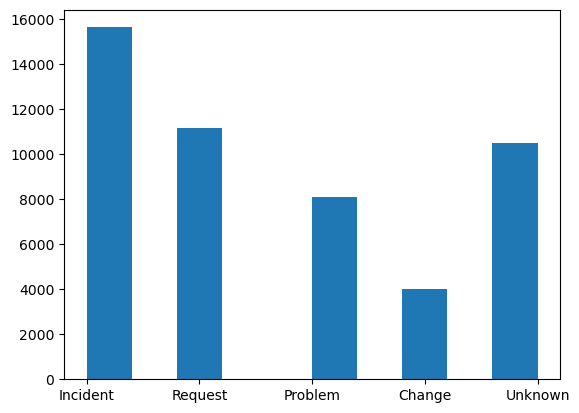

In [ ]:
plt.hist(df_train.type)
print('Распределение классов type:', df_train.type.value_counts()) #дисбаланс -> взвесть классы?

In [ ]:
print('Распределение классов queue:', df_train.queue.value_counts())

Распределение классов queue: queue
Technical Support                         11354
Product Support                            7139
Customer Service                           5905
IT Support                                 4673
Billing and Payments                       3853
Returns and Exchanges                      1956
Service Outages and Maintenance            1534
Sales and Pre-Sales                        1228
Human Resources                             730
General Inquiry                             532
News                                        313
Pets & Animals/Pet Services                 308
Autos & Vehicles/Sales                      287
Home & Garden/Home Improvement              285
IT & Technology/Security Operations         285
Shopping/E-commerce                         278
Health/Medical Services                     278
Pets & Animals/Veterinary Care              278
Health/Mental Health                        275
Jobs & Education/Online Courses             271
Trave

##### Длины текстов (в max какие-то очень большие значения, по сравнению с 75% квантилем, может выброс)

Длины текстов subject (краткое резюме или название билета)


count    49412.000000
mean         5.623007
std          2.934303
min          1.000000
25%          4.000000
50%          5.000000
75%          7.000000
max         89.000000
Name: subject, dtype: float64

Длины текстов body (полное описание проблемы)


count    49412.000000
mean        62.569173
std         34.586193
min          1.000000
25%         34.000000
50%         62.000000
75%         88.000000
max        340.000000
Name: body, dtype: float64

Длины текстов answer (ответ или продолжение обсуждения)


count    49412.000000
mean        48.791690
std         37.054774
min          1.000000
25%         16.000000
50%         47.000000
75%         79.000000
max        271.000000
Name: answer, dtype: float64

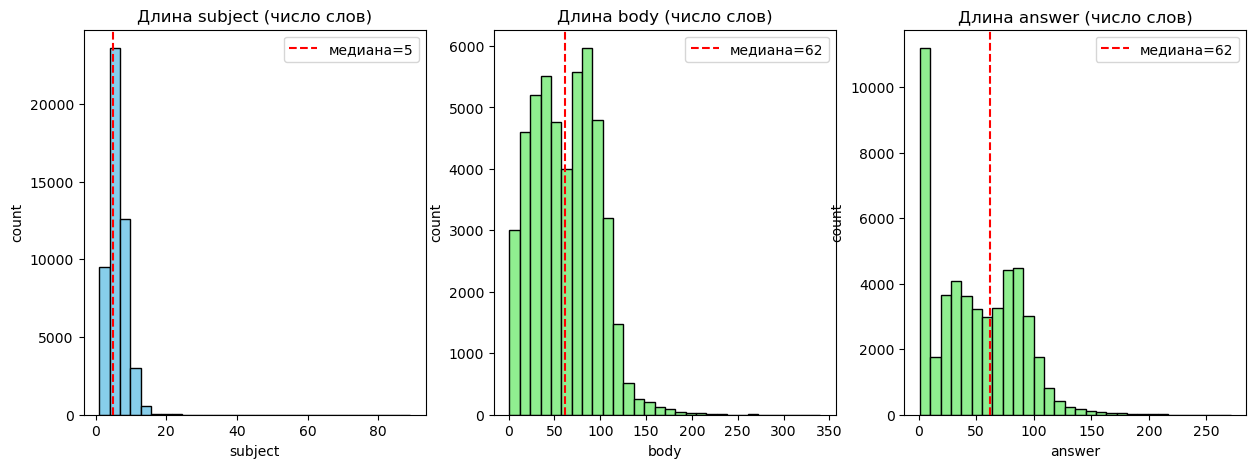

In [ ]:
def simple_tokenize(s: str):
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", str(s).lower())

print('Длины текстов subject (краткое резюме или название билета)')
display(df_train["subject"].apply(lambda s: len(simple_tokenize(s))).describe())

print('Длины текстов body (полное описание проблемы)')
display(df_train["body"].apply(lambda s: len(simple_tokenize(s))).describe())

print('Длины текстов answer (ответ или продолжение обсуждения)')
display(df_train["answer"].apply(lambda s: len(simple_tokenize(s))).describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

subject_lengths = df_train["subject"].apply(lambda s: len(simple_tokenize(str(s))))
axes[0].hist(subject_lengths, bins=30, color='skyblue', edgecolor='black')
axes[0].set_title("Длина subject (число слов)")
axes[0].set_xlabel("subject")
axes[0].set_ylabel("count")
# Добавим вертикальную линию для медианы
axes[0].axvline(subject_lengths.median(), color='red', linestyle='--', label=f'медиана={subject_lengths.median():.0f}')
axes[0].legend()

body_lengths = df_train["body"].apply(lambda s: len(simple_tokenize(str(s))))
axes[1].hist(body_lengths, bins=30, color='lightgreen', edgecolor='black')
axes[1].set_title("Длина body (число слов)")
axes[1].set_xlabel("body")
axes[1].set_ylabel("count")
# Добавим вертикальную линию для медианы
axes[1].axvline(body_lengths.median(), color='red', linestyle='--', label=f'медиана={body_lengths.median():.0f}')
axes[1].legend()

answer_lengths = df_train["answer"].apply(lambda s: len(simple_tokenize(str(s))))
axes[2].hist(answer_lengths, bins=30, color='lightgreen', edgecolor='black')
axes[2].set_title("Длина answer (число слов)")
axes[2].set_xlabel("answer")
axes[2].set_ylabel("count")
# Добавим вертикальную линию для медианы
axes[2].axvline(body_lengths.median(), color='red', linestyle='--', label=f'медиана={body_lengths.median():.0f}')
axes[2].legend()

#### Посмотрим, на строки где в subject много слов (может их перепутали с body?)

In [ ]:
# Находим строки где subject длиннее 7 слов
long_subjects = df_train[
    df_train["subject"].apply(lambda s: len(simple_tokenize(str(s)))) > 20
]

print(f"Найдено {len(long_subjects)} строк с subject > 20 слов")
print(f"Это {len(long_subjects)/len(df_train)*100:.2f}% от всех данных\n")

# Смотрим первые несколько
print("Примеры длинных subject'ов:")
for idx, row in long_subjects.head(10).iterrows():
    subject = row["subject"]
    word_count = len(simple_tokenize(str(subject)))
    print(f"\n[{word_count} слов] {subject}")

Найдено 78 строк с subject > 20 слов
Это 0.16% от всех данных

Примеры длинных subject'ов:

[89 слов] Liebe Kundensupport, benötige detaillierte Dokumentationen zu Sicherheitsprotokollen, Gesundheitsdienstleistungsdaten, Informatikinfrastruktur von Krankenhäusern. Als wertvoller Kunde möchte ich sicherstellen, dass vertrauliche Informationen geschützt sind. Könnten Sie bitte Informationen zu den Maßnahmen geben, die zur Bekämpfung von Datenverletzungen und cyberbasierten Bedrohungen eingesetzt werden? Ich wäre dankbar, wenn Sie Verschlüsselungsverfahren, Zugriffskontrolle und Notfallpläne einschließen würden, um meine Sicherheitsstrategie besser zu verstehen und Gewähr zu geben, dass meine Daten sicher sind. Vielen Dank für Ihre Unterstützung in dieser Angelegenheit.

[63 слов] Datenanalyse-System funktionierte korrekt, Optimierung von Investitionen durch Hürde gestiegen. Mögliche Ursachen für Probleme, wie Softwarefehler oder Schäden in der Datenintegration, wurden erfasst. Maßnahmen 

#### Посмотрим на body строк, у которых много слов в subject

In [ ]:
# def simple_tokenize(s: str):
#     return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?", str(s).lower())

long_subjects_mask = df_train["subject"].apply(lambda s: len(simple_tokenize(str(s)))) > 20
long_subjects = df_train[long_subjects_mask]

print(f"Найдено {len(long_subjects)} строк с subject > 20 слов")
print(f"Это {len(long_subjects)/len(df_train)*100:.2f}% от всех данных\n")

# 2. Теперь для каждого индекса в long_subjects считаем длину "на лету"
for idx, row in long_subjects.head(5).iterrows():
    # Считаем длину прямо здесь
    word_count = len(simple_tokenize(str(row['subject'])))

    print(f"\nSUBJECT ({word_count} слов):")
    print(row['subject'])
    print(f"\nBODY (первые 1000 символов):")
    print(str(row['body'])[:1000])
    print("-"*80)

Найдено 78 строк с subject > 20 слов
Это 0.16% от всех данных


SUBJECT (89 слов):
Liebe Kundensupport, benötige detaillierte Dokumentationen zu Sicherheitsprotokollen, Gesundheitsdienstleistungsdaten, Informatikinfrastruktur von Krankenhäusern. Als wertvoller Kunde möchte ich sicherstellen, dass vertrauliche Informationen geschützt sind. Könnten Sie bitte Informationen zu den Maßnahmen geben, die zur Bekämpfung von Datenverletzungen und cyberbasierten Bedrohungen eingesetzt werden? Ich wäre dankbar, wenn Sie Verschlüsselungsverfahren, Zugriffskontrolle und Notfallpläne einschließen würden, um meine Sicherheitsstrategie besser zu verstehen und Gewähr zu geben, dass meine Daten sicher sind. Vielen Dank für Ihre Unterstützung in dieser Angelegenheit.

BODY (первые 1000 символов):
Liebe [Name], vielen Dank für Ihre Besorgnis hinsichtlich der Sicherheit von Gesundheitsdienstleistungsdaten. Wir bieten robuste Sicherheitsprotokolle, die vertrauliche Informationen schützen, einschließlich Ver

##### Вроде все норм

#### По классам:

In [ ]:
df_train["n_words"] = df_train["subject"].apply(lambda s: len(simple_tokenize(s)))
df_train.groupby("type")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Change,4004.0,5.136613,2.926115,1.0,3.0,5.0,7.0,29.0
Incident,15632.0,4.997057,2.654742,1.0,4.0,5.0,6.0,63.0
Problem,8103.0,5.000740,2.808238,1.0,4.0,5.0,6.0,55.0
Request,11165.0,5.713748,3.261849,1.0,4.0,6.0,7.0,89.0
Unknown,10508.0,7.122954,2.475369,1.0,5.0,7.0,9.0,22.0


In [ ]:
df_train["n_words"] = df_train["body"].apply(lambda s: len(simple_tokenize(s)))
df_train.groupby("type")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Change,4004.0,63.335664,35.923361,2.0,31.0,68.0,86.0,259.0
Incident,15632.0,56.576126,33.462101,1.0,30.0,52.0,81.0,252.0
Problem,8103.0,55.855732,34.239245,1.0,29.0,50.0,81.0,340.0
Request,11165.0,59.772593,34.389508,1.0,30.0,60.0,84.0,273.0
Unknown,10508.0,79.340883,30.484722,6.0,54.0,87.0,103.0,172.0


In [ ]:
df_train["n_words"] = df_train["answer"].apply(lambda s: len(simple_tokenize(s)))
df_train.groupby("type")["n_words"].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Change,4004.0,64.806444,30.673842,2.0,38.00,68.0,87.0,238.0
Incident,15632.0,60.979529,31.236781,1.0,34.75,60.0,84.0,271.0
Problem,8103.0,60.732568,31.296697,1.0,35.00,59.0,84.0,221.0
Request,11165.0,62.297716,30.445916,1.0,36.00,64.0,84.0,214.0
Unknown,10508.0,1.000000,0.000000,1.0,1.00,1.0,1.0,1.0


=> у Unknown длинее subject и body (сложные тикеты) и нет ответа

#### Топ слова по классам

In [ ]:
df_train.language.value_counts() # 2 языка!!!

language
de    26799
en    22613
Name: count, dtype: int64

In [ ]:
df_train['text'] = df_train['subject'].fillna('') + ' ' + df_train['body'].fillna('')

#### Сначала удалим топ-слова

In [ ]:
# Определяем стоп-слова для обоих языков
STOP_EN = set(stopwords.words('english'))
STOP_DE = set(stopwords.words('german'))

# Добавляем общие стоп-слова (чтобы убрать мусор)
COMMON_STOP = {'the', 'and', 'for', 'with', 'you', 'your', 'this', 'that', 'dear',
               'are', 'have', 'from', 'please', 'would', 'could', 'should',
               'der', 'die', 'das', 'und', 'für', 'auf', 'bei', 'nach', 'aus',
               'ich', 'du', 'er', 'sie', 'es', 'wir', 'ihr', 'sie'}

STOP_EN.update(COMMON_STOP)
STOP_DE.update(COMMON_STOP)

# Функция для очистки текста от стоп-слов
def remove_stopwords(text, language):
    """
    Удаляет стоп-слова из текста с учетом языка
    """
    if pd.isna(text):
        return ""

    # Токенизируем
    tokens = simple_tokenize(text)

    # Выбираем стоп-слова по языку
    if language == 'de':
        stop_words = STOP_DE
    else:
        stop_words = STOP_EN

    # Оставляем только слова не из стоп-листа и длиннее 2 букв
    clean_tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return ' '.join(clean_tokens)

In [ ]:
X_train = df_train.apply(
    lambda row: remove_stopwords(row['text'], row['language']),
    axis=1)

In [ ]:
def top_words_by_lang(texts, languages, k=20):
    """
    Анализирует топ-слова отдельно для каждого языка
    """
    # Разделяем по языкам
    texts_en = []
    texts_de = []

    for text, lang in zip(texts, languages):
        if lang == 'de':
            texts_de.append(text)
        else:  # en или любой другой как en
            texts_en.append(text)

    print("\n" + "="*60)
    print("ТОП-СЛОВА ДЛЯ АНГЛИЙСКОГО:")
    print("="*60)
    c_en = Counter()
    for t in texts_en:
        toks = [w for w in simple_tokenize(t) if w not in STOP_EN and len(w) > 2]
        c_en.update(toks)

    for word, count in c_en.most_common(k):
        print(f"  {word}: {count}")

    print("\n" + "="*60)
    print("ТОП-СЛОВА ДЛЯ НЕМЕЦКОГО:")
    print("="*60)
    c_de = Counter()
    for t in texts_de:
        toks = [w for w in simple_tokenize(t) if w not in STOP_DE and len(w) > 2]
        c_de.update(toks)

    for word, count in c_de.most_common(k):
        print(f"  {word}: {count}")

    return c_en, c_de

# Использование
c_en, c_de = top_words_by_lang(X_train, df_train['language'], k=20)


ТОП-СЛОВА ДЛЯ АНГЛИЙСКОГО:
  data: 20172
  support: 12050
  issue: 11652
  assistance: 8959
  information: 7989
  software: 7973
  problem: 7814
  customer: 7779
  security: 7746
  provide: 7269
  medical: 7197
  analytics: 7109
  appreciate: 7021
  due: 6552
  investment: 6514
  integration: 6450
  digital: 6206
  system: 5994
  tools: 5426
  project: 5350

ТОП-СЛОВА ДЛЯ НЕМЕЦКОГО:
  problem: 21225
  support: 12381
  unterst: 11184
  tzung: 10410
  team: 9618
  nnten: 9169
  sung: 8924
  bitte: 8732
  nich: 7741
  ber: 6641
  ben: 6313
  dank: 6146
  glich: 6110
  informationen: 5794
  daten: 5110
  schreibe: 4939
  software: 4912
  system: 4906
  probleme: 4825
  geehrte: 4705


In [ ]:
for lab in sorted(df_train["type"].unique()):
    print(f"\n{'='*60}")
    print(f"ТИП: {lab}")
    print(f"{'='*60}")

    df_type = df_train[df_train["type"] == lab]

    # Английские тексты этого типа
    en_texts = df_type[df_type["language"] == "en"]["text"]
    if len(en_texts) > 0:
        print(f"\n--- Английский ({len(en_texts)} текстов) ---")
        c_en = Counter()
        for t in en_texts:
            toks = [w for w in simple_tokenize(t) if w not in STOP_EN and len(w) > 2]
            c_en.update(toks)
        print("  Топ-8 слов:")
        for word, count in c_en.most_common(8):
            print(f"    {word}: {count}")

    # Немецкие тексты этого типа
    de_texts = df_type[df_type["language"] == "de"]["text"]
    if len(de_texts) > 0:
        print(f"\n--- Немецкий ({len(de_texts)} текстов) ---")
        c_de = Counter()
        for t in de_texts:
            toks = [w for w in simple_tokenize(t) if w not in STOP_DE and len(w) > 2]
            c_de.update(toks)
        print("  Топ-8 слов:")
        for word, count in c_de.most_common(8):
            print(f"    {word}: {count}")


ТИП: Change

--- Английский (2383 текстов) ---
  Топ-8 слов:
    data: 2486
    request: 1551
    support: 1533
    security: 1304
    customer: 1239
    tools: 1222
    integration: 1169
    enhance: 1151

--- Немецкий (1621 текстов) ---
  Топ-8 слов:
    verbessern: 719
    bitte: 627
    aktualisierung: 579
    unserer: 542
    integration: 518
    tools: 517
    verbesserung: 494
    unterst: 485

ТИП: Incident

--- Английский (9039 текстов) ---
  Топ-8 слов:
    issue: 7685
    data: 7173
    problem: 5112
    software: 4605
    due: 4183
    support: 4174
    system: 3824
    assistance: 3604

--- Немецкий (6593 текстов) ---
  Топ-8 слов:
    problem: 5325
    software: 2496
    unterst: 2091
    issue: 2086
    tzung: 1960
    bitte: 1915
    system: 1860
    data: 1617

ТИП: Problem

--- Английский (4643 текстов) ---
  Топ-8 слов:
    data: 4101
    issue: 3847
    problem: 2690
    due: 2312
    software: 2136
    support: 2096
    assistance: 1974
    might: 1641

--- Немецк

In [ ]:
top_queues = df_train["queue"].value_counts().head(5)
print("Анализ самых частых QUEUE(тк их очень много):")

for queue_name in top_queues.index:
    print(f"\n{'='*60}")
    print(f"QUEUE: {queue_name} (всего {top_queues[queue_name]} тикетов)")
    print(f"{'='*60}")

    df_queue = df_train[df_train["queue"] == queue_name]

    # Английские тексты
    en_texts = df_queue[df_queue["language"] == "en"]["text"]
    if len(en_texts) > 0:
        print(f"\n--- Английский ({len(en_texts)} текстов) ---")
        c_en = Counter()
        for t in en_texts:
            toks = [w for w in simple_tokenize(t) if w not in STOP_EN and len(w) > 2]
            c_en.update(toks)
        print("  Топ-5 слов:")
        for word, count in c_en.most_common(5):
            print(f"    {word}: {count}")

    # Немецкие тексты
    de_texts = df_queue[df_queue["language"] == "de"]["text"]
    if len(de_texts) > 0:
        print(f"\n--- Немецкий ({len(de_texts)} текстов) ---")
        c_de = Counter()
        for t in de_texts:
            toks = [w for w in simple_tokenize(t) if w not in STOP_DE and len(w) > 2]
            c_de.update(toks)
        print("  Топ-5 слов:")
        for word, count in c_de.most_common(5):
            print(f"    {word}: {count}")

Анализ самых частых QUEUE(тк их очень много):

QUEUE: Technical Support (всего 11354 тикетов)

--- Английский (6570 текстов) ---
  Топ-5 слов:
    data: 6063
    issue: 4387
    support: 3426
    problem: 2983
    software: 2967

--- Немецкий (4784 текстов) ---
  Топ-5 слов:
    problem: 3081
    unterst: 1754
    software: 1748
    tzung: 1621
    bitte: 1500

QUEUE: Product Support (всего 7139 тикетов)

--- Английский (4208 текстов) ---
  Топ-5 слов:
    data: 4000
    issue: 2254
    support: 2172
    assistance: 1704
    security: 1511

--- Немецкий (2931 текстов) ---
  Топ-5 слов:
    problem: 1506
    unterst: 1116
    tzung: 997
    bitte: 922
    nnten: 875

QUEUE: Customer Service (всего 5905 тикетов)

--- Английский (3388 текстов) ---
  Топ-5 слов:
    data: 3341
    support: 1926
    information: 1429
    assistance: 1376
    provide: 1333

--- Немецкий (2517 текстов) ---
  Топ-5 слов:
    unterst: 1066
    nnten: 1011
    tzung: 946
    problem: 914
    informationen: 880



In [ ]:
for lab in sorted(df_train["priority"].unique()):
    print(f"\n{'='*60}")
    print(f"Приоретитность: {lab}")
    print(f"{'='*60}")

    df_type = df_train[df_train["priority"] == lab]

    # Английские тексты этого типа
    en_texts = df_type[df_type["language"] == "en"]["text"]
    if len(en_texts) > 0:
        print(f"\n--- Английский ({len(en_texts)} текстов) ---")
        c_en = Counter()
        for t in en_texts:
            toks = [w for w in simple_tokenize(t) if w not in STOP_EN and len(w) > 2]
            c_en.update(toks)
        print("  Топ-8 слов:")
        for word, count in c_en.most_common(8):
            print(f"    {word}: {count}")

    # Немецкие тексты этого типа
    de_texts = df_type[df_type["language"] == "de"]["text"]
    if len(de_texts) > 0:
        print(f"\n--- Немецкий ({len(de_texts)} текстов) ---")
        c_de = Counter()
        for t in de_texts:
            toks = [w for w in simple_tokenize(t) if w not in STOP_DE and len(w) > 2]
            c_de.update(toks)
        print("  Топ-8 слов:")
        for word, count in c_de.most_common(8):
            print(f"    {word}: {count}")


Приоретитность: critical

--- Немецкий (1516 текстов) ---
  Топ-8 слов:
    problem: 2146
    support: 1426
    team: 1173
    ausfall: 1087
    dringend: 1030
    sofortige: 915
    unterst: 818
    nich: 809

Приоретитность: high

--- Английский (8714 текстов) ---
  Топ-8 слов:
    data: 7728
    issue: 4754
    support: 4616
    assistance: 3521
    software: 3240
    problem: 3088
    security: 2987
    system: 2895

--- Немецкий (8832 текстов) ---
  Топ-8 слов:
    problem: 7311
    unterst: 3674
    tzung: 3456
    support: 3301
    bitte: 2579
    sung: 2444
    team: 2435
    nnten: 2282

Приоретитность: low

--- Английский (4670 текстов) ---
  Топ-8 слов:
    data: 4103
    support: 2498
    issue: 2376
    assistance: 1803
    information: 1781
    customer: 1707
    provide: 1685
    software: 1571

--- Немецкий (5610 текстов) ---
  Топ-8 слов:
    problem: 4025
    nnten: 2649
    support: 2533
    unterst: 2331
    nich: 2153
    tzung: 2149
    bitte: 2108
    team: 1954

#### Выводы:
1. Critical и Unknown - почти всегда немецкие
2. Billing - уникальные слова ("billing", "payment", "informationen")
3. Incident vs Problem:
 - Incident: "issue", "due" (срочные)
 - Problem: "might", "assistance" (менее срочные)  
4. Request: вежливые формы ("appreciate", "bitte", "könnten")

### Baseline: TF-IDF + линейная модель для queue

In [5]:
df_train["text"] = df_train["subject"].fillna("") + " " + df_train["body"].fillna("")
df_val["text"] = df_val["subject"].fillna("") + " " + df_val["body"].fillna("")
df_test["text"] = df_test["subject"].fillna("") + " " + df_test["body"].fillna("")

y_train_queue = df_train['queue'].astype(str)
y_val_queue = df_val['queue'].astype(str)
y_test_queue = df_test['queue'].astype(str)

In [6]:
X_train = df_train["text"]
X_val = df_val["text"]
X_test = df_test["text"]

In [ ]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,        # максимум признаков
        ngram_range=(1, 2),         # униграммы и биграммы
        min_df=2,                    # минимум в 2 документах
        max_df=0.95,                  # не больше чем в 95% документов
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(max_iter=2000))
])

tfidf_lr.fit(X_train, y_train_queue)
y_pred_lr = tfidf_lr.predict(X_test)

test_macro_f1_0 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_0 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_0:.4f}")
print(f"  Accuracy:  {test_accuracy_0:.4f}")


 Метрики на test:
  Macro-F1:  0.7464
  Accuracy:  0.5818


#### Добавим предобработку текста:

In [7]:
nltk.download('stopwords')
def simple_tokenize(s):
    return re.findall(r"[A-Za-zÄÖÜäöüß]+(?:'[A-Za-zÄÖÜäöüß]+)?", str(s).lower())

# Удаление стоп слов
STOP_EN = set(stopwords.words('english'))
STOP_DE = set(stopwords.words('german'))
# Добавляем общие стоп-слова (чтобы убрать мусор)
COMMON_STOP = {'the', 'and', 'for', 'with', 'you', 'your', 'this', 'that', 'dear',
               'are', 'have', 'from', 'please', 'would', 'could', 'should',
               'der', 'die', 'das', 'und', 'für', 'auf', 'bei', 'nach', 'aus',
               'ich', 'du', 'er', 'sie', 'es', 'wir', 'ihr', 'sie'}

STOP_EN.update(COMMON_STOP)
STOP_DE.update(COMMON_STOP)

def preprocess_text(text, language):
    if pd.isna(text):
        return ""

    # lowercase
    text = text.lower()

    # очистка
    text = re.sub(r'http\S+', ' URL ', text)
    text = re.sub(r'\S+@\S+', ' EMAIL ', text)
    text = re.sub(r'\d+', ' NUMBER ', text)

    # токенизация
    tokens = simple_tokenize(text)

    # стоп-слова
    stop_words = STOP_DE if language == 'de' else STOP_EN

    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    return " ".join(tokens)

X_train = df_train.apply(lambda r: preprocess_text(r["text"], r["language"]), axis=1)
X_test = df_test.apply(lambda r: preprocess_text(r["text"], r["language"]), axis=1)
X_val = df_val.apply(lambda r: preprocess_text(r["text"], r["language"]), axis=1)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,        # максимум признаков
        ngram_range=(1, 2),         # униграммы и биграммы
        min_df=2,                    # минимум в 2 документах
        max_df=0.95,                  # не больше чем в 95% документов
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(max_iter=2000))
])

tfidf_lr.fit(X_train, y_train_queue)
y_pred_lr = tfidf_lr.predict(X_test)

test_macro_f1_1 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_1 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_1:.4f}")
print(f"  Accuracy:  {test_accuracy_1:.4f}")


 Метрики на test:
  Macro-F1:  0.7810
  Accuracy:  0.5959


#### изменим параметры tf-idf (хуже)

In [ ]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,        # максимум признаков
        ngram_range=(1, 2),         # униграммы и биграммы
        min_df=5,                    # минимум в 5 документах
        max_df=0.9,                  # не больше чем в 90% документов
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(max_iter=2000))
])

tfidf_lr.fit(X_train, y_train_queue)
y_pred_lr = tfidf_lr.predict(X_test)

test_macro_f1_2 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_2 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_2:.4f}")
print(f"  Accuracy:  {test_accuracy_2:.4f}")


 Метрики на test:
  Macro-F1:  0.7677
  Accuracy:  0.5852


#### Попробуем Char TF-IDF (f1 лучше, accuracy хуже)

In [ ]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    min_df=5
)),
    ("clf", LogisticRegression(max_iter=2000))
])

tfidf_lr.fit(X_train, y_train_queue)
y_pred_lr = tfidf_lr.predict(X_test)

test_macro_f1_3 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_3 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_3:.4f}")
print(f"  Accuracy:  {test_accuracy_3:.4f}")


 Метрики на test:
  Macro-F1:  0.8018
  Accuracy:  0.5559


#### если включить subject 2 раза(тк он важнее)? (хуже)

In [ ]:
df_train["text"] = df_train["subject"] + " " + df_train["subject"] + " " + df_train["body"]
df_val["text"] = df_val["subject"] + " " + df_val["subject"] + " " + df_val["body"]
df_test["text"] = df_test["subject"] + " " + df_test["subject"] + " " + df_test["body"]

X_train = df_train.apply(lambda r: preprocess_text(r["text"], r["language"]), axis=1)
X_test = df_test.apply(lambda r: preprocess_text(r["text"], r["language"]), axis=1)
X_val = df_val.apply(lambda r: preprocess_text(r["text"], r["language"]), axis=1)

In [ ]:
tfidf_lr = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,        # максимум признаков
        ngram_range=(1, 2),         # униграммы и биграммы
        min_df=2,                    # минимум в 2 документах
        max_df=0.95,                  # не больше чем в 95% документов
        sublinear_tf=True,
    )),
    ("clf", LogisticRegression(max_iter=2000))
])

tfidf_lr.fit(X_train, y_train_queue)
y_pred_lr = tfidf_lr.predict(X_test)

test_macro_f1_4 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_4 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_4:.4f}")
print(f"  Accuracy:  {test_accuracy_4:.4f}")


 Метрики на test:
  Macro-F1:  0.7726
  Accuracy:  0.5660


#### два TF-IDF одновременно: для слов и для символов (лучшая на данный момент)

In [ ]:
word_tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    min_df=2
)

In [ ]:
features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
    #("length", length_transformer)
])

pipeline = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(max_iter=2000))
])

pipeline.fit(X_train, y_train_queue)

y_pred_lr = pipeline.predict(X_test)

test_macro_f1_5 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_5 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_5:.4f}")
print(f"  Accuracy:  {test_accuracy_5:.4f}")


 Метрики на test:
  Macro-F1:  0.8505
  Accuracy:  0.6152


#### добавим class_weight (f1 немного лучше, accuracy упал)

In [ ]:
word_tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95,
    max_features=50000
)

char_tfidf = TfidfVectorizer(
    analyzer="char_wb",
    ngram_range=(3,5),
    min_df=2
)

In [ ]:
features = FeatureUnion([
    ("word_tfidf", word_tfidf),
    ("char_tfidf", char_tfidf)
    #("length", length_transformer)
])

pipeline = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train_queue)

y_pred_lr = pipeline.predict(X_test)

test_macro_f1_6 = f1_score(y_test_queue, y_pred_lr, average='macro')
test_accuracy_6 = accuracy_score(y_test_queue, y_pred_lr)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_6:.4f}")
print(f"  Accuracy:  {test_accuracy_6:.4f}")


 Метрики на test:
  Macro-F1:  0.8565
  Accuracy:  0.5255


#### Настройка параметров для LogisticRegression

In [ ]:
pipe = Pipeline([
    ("features", features),
    ("clf", LogisticRegression(max_iter=2000))
])

scoring = {
    'macro_f1': make_scorer(f1_score, average='macro'),
    'accuracy': make_scorer(accuracy_score)
}

# Настройка кросс-валидации
#cv = StratifiedShuffleSplit(test_size=0.25, train_size=0.75, n_splits=3, random_state=42)

# Сетка параметров
param_grid = [
    {
        'classifier__penalty': ['l2'],
        'classifier__solver': ['newton-cg', 'lbfgs', 'sag', 'saga'],
        'classifier__C': [0.1, 1, 10]
    },
    {
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__C': [0.1, 1, 10]
    },
    {
        'classifier__penalty': [None],
        'classifier__solver': ['lbfgs', 'newton-cg'],
        'classifier__C': [0.1, 1, 10]
    }
]

# GridSearch
grid = GridSearchCV(
    pipe,
    param_grid,
    #cv=cv,
    return_train_score=True,
    scoring=scoring,
    refit='macro_f1',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train_queue)

print("Наилучшие параметры:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")

# Предсказания на validation
y_pred_val = grid.predict(X_val)

# Метрики на validation
val_macro_f1 = f1_score(y_val_queue, y_pred_val, average='macro')
val_accuracy = accuracy_score(y_val_queue, y_pred_val)

print(f"\n Метрики на validation:")
print(f"  Macro-F1:  {val_macro_f1:.4f}")
print(f"  Accuracy:  {val_accuracy:.4f}")

grid_result = pd.DataFrame(grid.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

Fitting 3 folds for each of 8 candidates, totalling 24 fits


KeyboardInterrupt: 

#### tf-idf + LinearSVC

In [ ]:
tfidf_svc = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=100000,        # максимум признаков
        ngram_range=(1, 2),         # униграммы и биграммы
        min_df=2,                    # минимум в 2 документах
        max_df=0.95,                  # не больше чем в 95% документов
        sublinear_tf=True,
    )),
    ("clf", LinearSVC(C=1,
                      class_weight="balanced",
                      max_iter=5000))
])

tfidf_svc.fit(X_train, y_train_queue)
y_pred_svc = tfidf_svc.predict(X_test)

test_macro_f1_7 = f1_score(y_test_queue, y_pred_svc, average='macro')
test_accuracy_7 = accuracy_score(y_test_queue, y_pred_svc)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_7:.4f}")
print(f"  Accuracy:  {test_accuracy_7:.4f}")


 Метрики на test:
  Macro-F1:  0.8764
  Accuracy:  0.6519


#### tf-idf + LinearSVC + char ngrams

In [ ]:
tfidf_svc = Pipeline([
    ("features", features),
    ("clf", LinearSVC(
        C=1,
        class_weight="balanced",
        max_iter=5000
    ))
])

tfidf_svc.fit(X_train, y_train_queue)

y_pred_svc = tfidf_svc.predict(X_test)

test_macro_f1_8 = f1_score(y_test_queue, y_pred_svc, average='macro')
test_accuracy_8 = accuracy_score(y_test_queue, y_pred_svc)

print(f"\n Метрики на test:")
print(f"  Macro-F1:  {test_macro_f1_8:.4f}")
print(f"  Accuracy:  {test_accuracy_8:.4f}")


 Метрики на test:
  Macro-F1:  0.8869
  Accuracy:  0.6328


### Сравнение метрик моделей для queue

In [ ]:
rows = []

rows.append({"method": "TF‑IDF + LR", "macro_f1": test_macro_f1_1, "accuracy": test_accuracy_1})
rows.append({"method": "TF‑IDF + LR + char ngrams", "macro_f1": test_macro_f1_5, "accuracy": test_accuracy_5})
rows.append({"method": "TF‑IDF + LR(class weight) + char ngrams", "macro_f1": test_macro_f1_6, "accuracy": test_accuracy_6})
rows.append({"method": "TF‑IDF + LinearSVC", "macro_f1": test_macro_f1_7, "accuracy": test_accuracy_7})
rows.append({"method": "TF‑IDF + LinearSVC + char ngrams", "macro_f1": test_macro_f1_8, "accuracy": test_accuracy_8})

res = pd.DataFrame(rows).sort_values("macro_f1", ascending=False)
res

,method,macro_f1,accuracy
4,TF‑IDF + LinearSVC + char ngrams,0.886915,0.632831
3,TF‑IDF + LinearSVC,0.876433,0.651935
2,TF‑IDF + LR(class weight) + char ngrams,0.856468,0.525498
1,TF‑IDF + LR + char ngrams,0.850511,0.615185
0,TF‑IDF + LR,0.780952,0.595920


### Transformer fine-tuning на multitask (queue, priority, type)

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [9]:
MODEL_NAME = "xlm-roberta-base" # мультиязычная модель

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [11]:
# Dataset для multitask
class TicketDataset(Dataset):
    def __init__(self, texts, queue, priority, type_, tokenizer, max_length=128):
        self.texts = list(texts)
        self.queue = list(queue)
        self.priority = list(priority)
        self.type = list(type_)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        item = {k: v.squeeze(0) for k, v in enc.items()}

        item["queue"] = torch.tensor(self.queue[idx], dtype=torch.long)
        item["priority"] = torch.tensor(self.priority[idx], dtype=torch.long)
        item["type"] = torch.tensor(self.type[idx], dtype=torch.long)

        return item

In [12]:
# Multitask модель
class MultiTaskModel(nn.Module):
    def __init__(self, model_name, n_queue, n_priority, n_type):
        super().__init__()

        self.encoder = AutoModel.from_pretrained(model_name)

        hidden = self.encoder.config.hidden_size

        self.queue_head = nn.Linear(hidden, n_queue)
        self.priority_head = nn.Linear(hidden, n_priority)
        self.type_head = nn.Linear(hidden, n_type)

    def forward(self, input_ids, attention_mask):

        out = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls = out.last_hidden_state[:,0]

        queue_logits = self.queue_head(cls)
        priority_logits = self.priority_head(cls)
        type_logits = self.type_head(cls)

        return queue_logits, priority_logits, type_logits


In [13]:
# остальные y
y_train_priority = df_train['priority'].astype(str)
y_val_priority   = df_val['priority'].astype(str)
y_test_priority  = df_test['priority'].astype(str)

y_train_type = df_train['type'].astype(str)
y_val_type   = df_val['type'].astype(str)
y_test_type  = df_test['type'].astype(str)

# кодируем лейблы
le_queue = LabelEncoder()

y_train_queue_id = le_queue.fit_transform(y_train_queue)
y_val_queue_id   = le_queue.transform(y_val_queue)
y_test_queue_id  = le_queue.transform(y_test_queue)

le_priority = LabelEncoder()

y_train_priority_id = le_priority.fit_transform(y_train_priority)
y_val_priority_id   = le_priority.transform(y_val_priority)
y_test_priority_id  = le_priority.transform(y_test_priority)

le_type = LabelEncoder()

y_train_type_id = le_type.fit_transform(y_train_type)
y_val_type_id   = le_type.transform(y_val_type)
y_test_type_id  = le_type.transform(y_test_type)


train_ds = TicketDataset(
    X_train,
    y_train_queue_id,
    y_train_priority_id,
    y_train_type_id,
    tokenizer,
    max_length=128
)

val_ds = TicketDataset(
    X_val,
    y_val_queue_id,
    y_val_priority_id,
    y_val_type_id,
    tokenizer,
    max_length=128
)

test_ds = TicketDataset(
    X_test,
    y_test_queue_id,
    y_test_priority_id,
    y_test_type_id,
    tokenizer,
    max_length=128
)


train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=16, shuffle=False)

In [14]:
# модель
model = MultiTaskModel(
    MODEL_NAME,
    n_queue=len(le_queue.classes_),
    n_priority=len(le_priority.classes_),
    n_type=len(le_type.classes_)
).to(device)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [15]:
optimizer = AdamW(model.parameters(), lr=2e-5)

ce = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):

    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    losses = []

    q_pred, q_true = [], []
    p_pred, p_true = [], []
    t_pred, t_true = [], []

    for batch in loader:

        batch = {k: v.to(device) for k,v in batch.items()}

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        queue = batch["queue"]
        priority = batch["priority"]
        type_ = batch["type"]

        if train_mode:

            q_logits, p_logits, t_logits = model(input_ids, attention_mask)

            loss_q = ce(q_logits, queue)
            loss_p = ce(p_logits, priority)
            loss_t = ce(t_logits, type_)

            loss = loss_q + loss_p + loss_t

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        else:
            with torch.no_grad():
                q_logits, p_logits, t_logits = model(input_ids, attention_mask)

                loss_q = ce(q_logits, queue)
                loss_p = ce(p_logits, priority)
                loss_t = ce(t_logits, type_)

                loss = loss_q + loss_p + loss_t

        losses.append(loss.item())

        q_pred.append(q_logits.argmax(1).cpu().numpy())
        q_true.append(queue.cpu().numpy())

        p_pred.append(p_logits.argmax(1).cpu().numpy())
        p_true.append(priority.cpu().numpy())

        t_pred.append(t_logits.argmax(1).cpu().numpy())
        t_true.append(type_.cpu().numpy())

    return (
        np.mean(losses),
        np.concatenate(q_true), np.concatenate(q_pred),
        np.concatenate(p_true), np.concatenate(p_pred),
        np.concatenate(t_true), np.concatenate(t_pred),
    )

In [16]:
# Обучение
for epoch in range(2):
    train_loss, *_ = run_epoch(model, train_loader, optimizer)
    val_loss, q_true, q_pred, p_true, p_pred, t_true, t_pred = run_epoch(
        model, val_loader
    )

    #print(f"\nEpoch {epoch}")
    print(f"\nEpoch {epoch}", flush=True)
    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
    print("queue MacroF1:", f1_score(q_true, q_pred, average="macro"))
    print("priority Acc:", accuracy_score(p_true, p_pred))
    print("type Acc:", accuracy_score(t_true, t_pred))

test_loss, q_true, q_pred, p_true, p_pred, t_true, t_pred = run_epoch(
    model, test_loader
)

macro_f1_queue = f1_score(q_true, q_pred, average="macro")
acc_priority = accuracy_score(p_true, p_pred)
acc_type = accuracy_score(t_true, t_pred)

score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

print(f"\n Результаты на test:")
print(f"  queue Macro-F1:  {macro_f1_queue:.4f}")
print(f"  priority Acc:    {acc_priority:.4f}")
print(f"  type Acc:        {acc_type:.4f}")
print(f"\n ИТОГОВЫЙ SCORE: {score:.4f}")


Epoch 0
Train loss: 3.4008, Val loss: 2.6975
queue MacroF1: 0.6588927335395648
priority Acc: 0.5289831606217616
type Acc: 0.833711139896373

Epoch 1
Train loss: 2.5442, Val loss: 2.4071
queue MacroF1: 0.7957022000810513
priority Acc: 0.5939119170984456
type Acc: 0.8633419689119171

 Результаты на test:
  queue Macro-F1:  0.7853
  priority Acc:    0.5739
  type Acc:        0.8583

 ИТОГОВЫЙ SCORE: 0.7645


### Попробуем использовать взвешенную функцию потерь

In [22]:
optimizer = AdamW(model.parameters(), lr=2e-5)

ce = nn.CrossEntropyLoss()

def run_epoch(model, loader, optimizer=None):

    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    losses = []

    q_pred, q_true = [], []
    p_pred, p_true = [], []
    t_pred, t_true = [], []

    for batch in loader:

        batch = {k: v.to(device) for k,v in batch.items()}

        input_ids = batch["input_ids"]
        attention_mask = batch["attention_mask"]

        queue = batch["queue"]
        priority = batch["priority"]
        type_ = batch["type"]

        if train_mode:

            q_logits, p_logits, t_logits = model(input_ids, attention_mask)

            loss_q = ce(q_logits, queue)
            loss_p = ce(p_logits, priority)
            loss_t = ce(t_logits, type_)

            #loss = loss_q + loss_p + loss_t
            loss = 0.7 * loss_q + 0.15 * loss_p + 0.15 * loss_t

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        else:
            with torch.no_grad():
                q_logits, p_logits, t_logits = model(input_ids, attention_mask)

                loss_q = ce(q_logits, queue)
                loss_p = ce(p_logits, priority)
                loss_t = ce(t_logits, type_)

                #loss = loss_q + loss_p + loss_t
                loss = 0.7 * loss_q + 0.15 * loss_p + 0.15 * loss_t

        losses.append(loss.item())

        q_pred.append(q_logits.argmax(1).cpu().numpy())
        q_true.append(queue.cpu().numpy())

        p_pred.append(p_logits.argmax(1).cpu().numpy())
        p_true.append(priority.cpu().numpy())

        t_pred.append(t_logits.argmax(1).cpu().numpy())
        t_true.append(type_.cpu().numpy())

    return (
        np.mean(losses),
        np.concatenate(q_true), np.concatenate(q_pred),
        np.concatenate(p_true), np.concatenate(p_pred),
        np.concatenate(t_true), np.concatenate(t_pred),
    )

In [23]:
# Обучение
for epoch in range(2):
    train_loss, *_ = run_epoch(model, train_loader, optimizer)
    val_loss, q_true, q_pred, p_true, p_pred, t_true, t_pred = run_epoch(
        model, val_loader
    )

    #print(f"\nEpoch {epoch}")
    print(f"\nEpoch {epoch}", flush=True)
    print(f"Train loss: {train_loss:.4f}, Val loss: {val_loss:.4f}")
    print("queue MacroF1:", f1_score(q_true, q_pred, average="macro"))
    print("priority Acc:", accuracy_score(p_true, p_pred))
    print("type Acc:", accuracy_score(t_true, t_pred))

test_loss, q_true, q_pred, p_true, p_pred, t_true, t_pred = run_epoch(
    model, test_loader
)

macro_f1_queue = f1_score(q_true, q_pred, average="macro")
acc_priority = accuracy_score(p_true, p_pred)
acc_type = accuracy_score(t_true, t_pred)

score = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

print(f"\n Результаты на test:")
print(f"  queue Macro-F1:  {macro_f1_queue:.4f}")
print(f"  priority Acc:    {acc_priority:.4f}")
print(f"  type Acc:        {acc_type:.4f}")
print(f"\n ИТОГОВЫЙ SCORE: {score:.4f}")


Epoch 0
Train loss: 1.0333, Val loss: 0.9960
queue MacroF1: 0.8354913034448143
priority Acc: 0.6008743523316062
type Acc: 0.8602655440414507

Epoch 1
Train loss: 0.8917, Val loss: 0.9755
queue MacroF1: 0.8497041549509945
priority Acc: 0.6050841968911918
type Acc: 0.8613989637305699

 Результаты на test:
  queue Macro-F1:  0.8540
  priority Acc:    0.5922
  type Acc:        0.8605

 ИТОГОВЫЙ SCORE: 0.8157


### Сonfidence (уверенность модели)

In [24]:
def get_confidence_from_logits(logits):
    """
    Преобразует логиты в вероятности и возвращает уверенность
    (максимальная вероятность)
    """
    probs = torch.softmax(logits, dim=1)
    confidence = probs.max(dim=1)[0].cpu().numpy()
    return confidence

def evaluate_with_confidence_threshold(model, loader, threshold_percent=70, task='queue'):
    """
    Оценивает модель, оставляя только top X% самых уверенных предсказаний

    Args:
        model: обученная модель
        loader: DataLoader (test)
        threshold_percent: какой процент самых уверенных оставить (70 = топ 70%)
        task: 'queue', 'priority', или 'type'

    Returns:
        метрики на отфильтрованных данных и доля оставленных примеров
    """
    model.eval()

    all_preds = []
    all_true = []
    all_confidences = []

    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            q_logits, p_logits, t_logits = model(
                batch['input_ids'],
                batch['attention_mask']
            )

            # Выбираем нужную задачу
            if task == 'queue':
                logits = q_logits
                true = batch['queue']
            elif task == 'priority':
                logits = p_logits
                true = batch['priority']
            else:  # type
                logits = t_logits
                true = batch['type']

            # Предсказания и уверенность
            preds = logits.argmax(dim=1)
            confidence = get_confidence_from_logits(logits)

            all_preds.extend(preds.cpu().numpy())
            all_true.extend(true.cpu().numpy())
            all_confidences.extend(confidence)

    # Преобразуем в numpy
    all_preds = np.array(all_preds)
    all_true = np.array(all_true)
    all_confidences = np.array(all_confidences)

    # Сортируем по уверенности (от самой высокой к низкой)
    sorted_indices = np.argsort(all_confidences)[::-1]

    # Берем top threshold_percent%
    n_keep = int(len(all_confidences) * threshold_percent / 100)
    keep_indices = sorted_indices[:n_keep]

    # Метрики на отфильтрованных данных
    if task == 'queue':
        metric = f1_score(all_true[keep_indices], all_preds[keep_indices], average='macro')
        metric_name = 'Macro-F1'
    else:
        metric = accuracy_score(all_true[keep_indices], all_preds[keep_indices])
        metric_name = 'Accuracy'

    return {
        'metric': metric,
        'metric_name': metric_name,
        'kept_ratio': n_keep / len(all_confidences),
        'kept_count': n_keep,
        'total_count': len(all_confidences),
        'all_confidences': all_confidences,
        'all_preds': all_preds,
        'all_true': all_true
    }

In [29]:
def confidence_analysis(model, loader, tasks=['queue', 'priority', 'type']):
    """
    Анализирует качество модели при разных порогах уверенности
    для всех трёх задач
    """
    results = []

    # Пробуем разные пороги от 20% до 100%
    thresholds = [20, 40, 60, 70, 80, 90, 100]

    for task in tasks:
        print(f"\n Анализ для задачи: {task}")

        for thresh in thresholds:
            res = evaluate_with_confidence_threshold(
                model, loader, threshold_percent=thresh, task=task
            )

            results.append({
                'task': task,
                'threshold_%': thresh,
                'kept_%': res['kept_ratio'] * 100,
                'metric': res['metric'],
                'metric_name': res['metric_name'],
                'kept_count': res['kept_count']
            })

            print(f"  {thresh:3d}% → {res['kept_ratio']*100:5.1f}% данных, "
                  f"{res['metric_name']}: {res['metric']:.4f}")

    return pd.DataFrame(results)

In [26]:
def plot_confidence_analysis(df_results):
    """
    Строит график зависимости качества от порога уверенности
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, task in enumerate(['queue', 'priority', 'type']):
        ax = axes[idx]
        task_data = df_results[df_results['task'] == task]

        ax.plot(task_data['threshold_%'], task_data['metric'],
                marker='o', linewidth=2, markersize=8)
        ax.axhline(y=task_data[task_data['threshold_%'] == 100]['metric'].values[0],
                   linestyle='--', color='gray', alpha=0.7, label='Без фильтрации')

        ax.set_xlabel('Порог уверенности (% самых уверенных)')
        if task == 'queue':
            ax.set_ylabel('Macro-F1')
            ax.set_title(f'Queue: Macro-F1 при разном confidence')
        else:
            ax.set_ylabel('Accuracy')
            ax.set_title(f'{task.capitalize()}: Accuracy при разном confidence')

        ax.grid(True, alpha=0.3)
        ax.legend()

        # Добавим подписи для 70% порога
        if 70 in task_data['threshold_%'].values:
            y70 = task_data[task_data['threshold_%'] == 70]['metric'].values[0]
            ax.plot(70, y70, 'ro', markersize=10)
            ax.annotate(f'{y70:.3f}', (70, y70), xytext=(5, 5),
                       textcoords='offset points', fontsize=10, color='red')

    plt.tight_layout()
    plt.suptitle('Анализ confidence: качество на самых уверенных предсказаниях',
                 y=1.02, fontsize=14)
    plt.show()

In [27]:
def manual_labeling_analysis(df_results):
    """
    Анализирует, сколько данных можно отправить на ручную разметку
    и какое качество будет на автоматической обработке
    """
    print("\n" + "="*80)
    print("АНАЛИЗ ДЛЯ РУЧНОЙ РАЗМЕТКИ")
    print("="*80)

    # Анализируем для порога 70% (30% на ручную разметку)
    threshold_70 = df_results[df_results['threshold_%'] == 70]

    print("\n При пороге 70% (30% на ручную разметку):")
    for _, row in threshold_70.iterrows():
        auto_quality = row['metric']
        manual_percent = 100 - row['kept_%']

        print(f"\n  {row['task']}:")
        print(f"    Автоматически: {row['kept_%']:.1f}% данных")
        print(f"    Качество на авто: {row['metric_name']} = {auto_quality:.4f}")
        print(f"    Ручная разметка: {manual_percent:.1f}% данных")

    # Таблица для всех порогов
    print("\n" + "="*80)
    print("СВОДНАЯ ТАБЛИЦА (все пороги)")
    print("="*80)

    pivot = df_results.pivot_table(
        values='metric',
        index='threshold_%',
        columns='task'
    ).round(4)

    # Добавляем колонку с процентом данных
    pivot['data_kept_%'] = df_results[df_results['task'] == 'queue']['kept_%'].values

    # Переставляем колонки
    pivot = pivot[['data_kept_%', 'queue', 'priority', 'type']]

    print("\nЗависимость качества от порога уверенности:")
    print(pivot.to_string())

    return pivot

In [30]:
# Проводим анализ
print(" Анализируем confidence на test данных...")
results_df = confidence_analysis(model, test_loader)

 Анализируем confidence на test данных...

 Анализ для задачи: queue
   20% →  20.0% данных, Macro-F1: 0.9991
   40% →  40.0% данных, Macro-F1: 0.9125
   60% →  60.0% данных, Macro-F1: 0.8813
   70% →  70.0% данных, Macro-F1: 0.8734
   80% →  80.0% данных, Macro-F1: 0.8672
   90% →  90.0% данных, Macro-F1: 0.8605
  100% → 100.0% данных, Macro-F1: 0.8540

 Анализ для задачи: priority
   20% →  20.0% данных, Accuracy: 0.9344
   40% →  40.0% данных, Accuracy: 0.7757
   60% →  60.0% данных, Accuracy: 0.6897
   70% →  70.0% данных, Accuracy: 0.6579
   80% →  80.0% данных, Accuracy: 0.6333
   90% →  90.0% данных, Accuracy: 0.6122
  100% → 100.0% данных, Accuracy: 0.5922

 Анализ для задачи: type
   20% →  20.0% данных, Accuracy: 0.9984
   40% →  40.0% данных, Accuracy: 0.9972
   60% →  60.0% данных, Accuracy: 0.9803
   70% →  70.0% данных, Accuracy: 0.9540
   80% →  80.0% данных, Accuracy: 0.9265
   90% →  90.0% данных, Accuracy: 0.8946
  100% → 100.0% данных, Accuracy: 0.8605


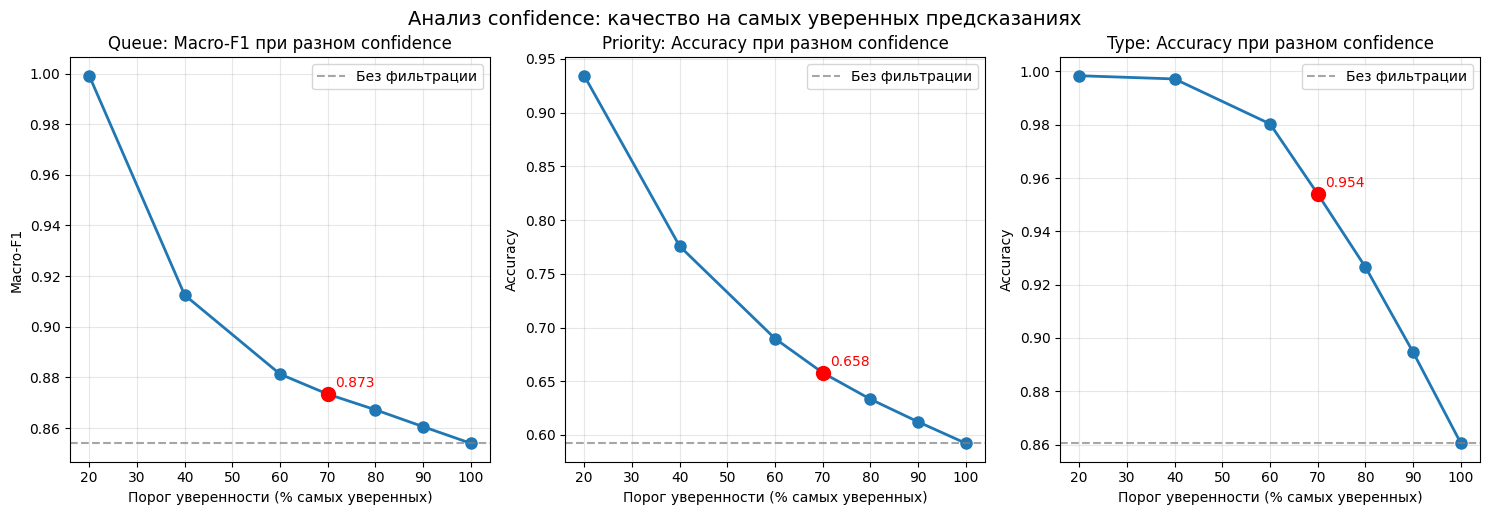


АНАЛИЗ ДЛЯ РУЧНОЙ РАЗМЕТКИ

 При пороге 70% (30% на ручную разметку):

  queue:
    Автоматически: 70.0% данных
    Качество на авто: Macro-F1 = 0.8734
    Ручная разметка: 30.0% данных

  priority:
    Автоматически: 70.0% данных
    Качество на авто: Accuracy = 0.6579
    Ручная разметка: 30.0% данных

  type:
    Автоматически: 70.0% данных
    Качество на авто: Accuracy = 0.9540
    Ручная разметка: 30.0% данных

СВОДНАЯ ТАБЛИЦА (все пороги)

Зависимость качества от порога уверенности:
task         data_kept_%   queue  priority    type
threshold_%                                       
20             19.993524  0.9991    0.9344  0.9984
40             39.987049  0.9125    0.7757  0.9972
60             59.996762  0.8813    0.6897  0.9803
70             69.985430  0.8734    0.6579  0.9540
80             79.990287  0.8672    0.6333  0.9265
90             89.995143  0.8605    0.6122  0.8946
100           100.000000  0.8540    0.5922  0.8605


In [31]:
# Визуализируем
plot_confidence_analysis(results_df)

# Бизнес-выводы
pivot_table = manual_labeling_analysis(results_df)

Следовательно, если отправлять 30% самых сложных случаев на ручную разметку, качество на автоматически обработанных 70% будет:
- Queue: 87.34% (вместо 85.4%)
- Priority: 65.79% (вместо 59.22%)
- Type: 95.4% (вместо 86.05%)